# MM-Net — Supplementary Analysis and Figures
Retrains the headline model once (seed 42, identical to `MM_Net_reproduction.ipynb`), saves its
artifacts, and produces the corrected clinical analyses and the clean result figures. The
modality-ablation numbers are read from the main notebook's live outputs.

## Setup, data, model, training (same code as the main notebook)

In [1]:
import os, sys, glob, json, re, warnings, time
import numpy as np
warnings.filterwarnings("ignore")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK","TRUE")
if os.path.basename(os.getcwd())=="revision": os.chdir("..")
sys.path.insert(0, os.path.abspath("processing"))
import torch, torch.nn as nn
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
DEV="cuda" if torch.cuda.is_available() else "cpu"; L,NC,EPS=20,5,1e-12; CLS=["W","N1","N2","N3","R"]
FE="data/mm_features"; DUP={28}
def load_data():
    d={}
    for f in sorted(glob.glob(os.path.join(FE,"SN*.npz")),key=lambda p:int(os.path.basename(p)[2:-4])):
        sid=int(os.path.basename(f)[2:-4])
        if sid in DUP: continue
        z=np.load(f); Fe=np.nan_to_num(z["Feeg"]).astype(np.float32); Fc=np.nan_to_num(z["Fcard"]).astype(np.float32)
        Fe=(Fe-Fe.mean(0))/(Fe.std(0)+1e-6); Fc=(Fc-Fc.mean(0))/(Fc.std(0)+1e-6)
        d[sid]=(Fe,Fc,z["y"].astype(np.int64),z["apnea"].astype(np.int64))
    return d
DATA=load_data(); SUBS=sorted(DATA)
def make_folds(subs,k=10,seed=42):
    r=np.random.RandomState(seed); s=list(subs); r.shuffle(s); folds=[s[i::k] for i in range(k)]
    return [([x for j,f in enumerate(folds) if j!=i for x in f],folds[i]) for i in range(k)]
FOLDS=make_folds(SUBS)
class FeatMLP(nn.Module):
    def __init__(s,fin,d,drop=0.3):
        super().__init__(); s.net=nn.Sequential(nn.Linear(fin,d),nn.LayerNorm(d),nn.GELU(),nn.Dropout(drop),nn.Linear(d,d),nn.LayerNorm(d),nn.GELU(),nn.Dropout(drop))
    def forward(s,x): return s.net(x)
class MMFeatureNet(nn.Module):
    def __init__(s,d=128,dc=64,h=128,drop=0.3):
        super().__init__(); s.eeg=FeatMLP(188,d,drop); s.card=FeatMLP(14,dc,drop)
        s.fuse=nn.Sequential(nn.Linear(d+dc,d),nn.GELU(),nn.Dropout(drop))
        s.lstm=nn.LSTM(d,h,2,batch_first=True,bidirectional=True,dropout=drop)
        s.stage=nn.Linear(2*h,5); s.apn=nn.Sequential(nn.Linear(2*h+dc,h),nn.GELU(),nn.Dropout(drop),nn.Linear(h,1))
    def forward(s,fe,fc):
        B,Ln=fe.shape[:2]; e=s.eeg(fe.reshape(B*Ln,-1)); c=s.card(fc.reshape(B*Ln,-1))
        hh,_=s.lstm(s.fuse(torch.cat([e,c],-1)).reshape(B,Ln,-1))
        return s.stage(hh), s.apn(torch.cat([hh,c.reshape(B,Ln,-1)],-1)).squeeze(-1)
def wins(subs,stride):
    Fe,Fc,Y,A,M=[],[],[],[],[]
    for sname in subs:
        fe,fc,y,a=DATA[sname]; n=len(y)
        for st in range(0,max(1,n-L+1),stride):
            e,cc,yy,aa=fe[st:st+L],fc[st:st+L],y[st:st+L],a[st:st+L]; m=np.ones(len(yy),np.float32)
            if len(yy)<L:
                k=L-len(yy); e=np.concatenate([e,np.zeros((k,188),np.float32)]); cc=np.concatenate([cc,np.zeros((k,14),np.float32)])
                yy=np.concatenate([yy,np.zeros(k,np.int64)]); aa=np.concatenate([aa,np.zeros(k,np.int64)]); m=np.concatenate([m,np.zeros(k,np.float32)])
            Fe.append(e); Fc.append(cc); Y.append(yy); A.append(aa); M.append(m)
    t=lambda a,d: torch.tensor(np.asarray(a),dtype=d,device=DEV)
    return t(Fe,torch.float32),t(Fc,torch.float32),t(Y,torch.long),t(A,torch.float32),t(M,torch.float32)
def sqcw(tr):
    cc=np.zeros(5,np.int64)
    for sname in tr: cc+=np.bincount(DATA[sname][2],minlength=5)
    inv=np.sqrt(cc.sum()/(5*np.maximum(cc,1))); return torch.tensor(inv/inv.mean(),dtype=torch.float32,device=DEV)
def hmm(Al,pl,lp):
    T=lp.shape[0]; dp=np.zeros((T,NC)); bp=np.zeros((T,NC),int); dp[0]=pl+lp[0]
    for t in range(1,T): sc=dp[t-1][:,None]+Al; bp[t]=sc.argmax(0); dp[t]=sc.max(0)+lp[t]
    p=np.zeros(T,int); p[-1]=dp[-1].argmax()
    for t in range(T-2,-1,-1): p[t]=bp[t+1,p[t+1]]
    return p
@torch.no_grad()
def infer(model,sname):
    model.eval(); fe,fc,y,a=DATA[sname]; n=len(y); pad=(-n)%L
    if pad: fe=np.concatenate([fe,np.zeros((pad,188),np.float32)]); fc=np.concatenate([fc,np.zeros((pad,14),np.float32)])
    fe=torch.tensor(fe.reshape(-1,L,188),device=DEV); fc=torch.tensor(fc.reshape(-1,L,14),device=DEV)
    so,ao,hs=[],[],[]; cap={}; hk=model.lstm.register_forward_hook(lambda m,i,o:cap.__setitem__("h",o[0].detach()))
    for i in range(0,len(fe),32):
        s_o,a_o=model(fe[i:i+32],fc[i:i+32]); so.append(s_o.softmax(-1).reshape(-1,5).cpu().numpy())
        ao.append(torch.sigmoid(a_o).reshape(-1).cpu().numpy()); hs.append(cap["h"].reshape(-1,cap["h"].shape[-1]).cpu().numpy())
    hk.remove(); return np.concatenate(so)[:n],np.concatenate(ao)[:n],np.concatenate(hs)[:n]
def train_fold(tr,va,epochs=45,patience=8,bs=32,seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    Fe,Fc,Y,A,M=wins(tr,L//2); N=Fe.shape[0]; model=MMFeatureNet().to(DEV)
    opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4); sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs)
    ce=nn.CrossEntropyLoss(weight=sqcw(tr),reduction="none"); ac=np.zeros(2,np.int64)
    for sname in tr: ac+=np.bincount(DATA[sname][3],minlength=2)
    bce=nn.BCEWithLogitsLoss(reduction="none",pos_weight=torch.tensor([ac[0]/max(1,ac[1])],dtype=torch.float32,device=DEV))
    best,bs_,bad=-1,None,0
    for ep in range(epochs):
        model.train(); perm=torch.randperm(N,device=DEV)
        for i in range(0,N-bs+1,bs):
            idx=perm[i:i+bs]; s_o,a_o=model(Fe[idx],Fc[idx]); m=M[idx].reshape(-1)
            ls=(ce(s_o.reshape(-1,5),Y[idx].reshape(-1))*m).sum()/m.sum().clamp(min=1)
            la=(bce(a_o.reshape(-1),A[idx].reshape(-1))*m).sum()/m.sum().clamp(min=1)
            opt.zero_grad(); (ls+la).backward(); nn.utils.clip_grad_norm_(model.parameters(),5.0); opt.step()
        sch.step()
        acc=np.mean([(infer(model,s)[0].argmax(1)==DATA[s][2]).mean() for s in va])
        if acc>best: best,bad,bs_=acc,0,{k:v.detach().clone() for k,v in model.state_dict().items()}
        else: bad+=1
        if bad>=patience: break
    model.load_state_dict(bs_); return model
print("ready | device", DEV, "| subjects", len(SUBS))

ready | device cuda | subjects 96


## 1. Retrain the headline (seed 42 = identical to the main notebook), save artifacts

In [2]:
t=time.time(); PS={}; EMB=[]; EY=[]; EA=[]; YT=[]; YP=[]
for fi,(tr_all,te) in enumerate(FOLDS):
    rng=np.random.RandomState(100+fi); tr_all=list(tr_all); rng.shuffle(tr_all)
    nv=max(10,len(tr_all)//9); va,tr=tr_all[:nv],tr_all[nv:]
    Am=np.ones((NC,NC)); pi=np.ones(NC)
    for s in tr:
        y=DATA[s][2]; pi[y[0]]+=1
        for x,z in zip(y[:-1],y[1:]): Am[x,z]+=1
    Al=np.log(Am/Am.sum(1,keepdims=True)); pl=np.log(pi/pi.sum())
    model=train_fold(tr,va)
    if fi==0:
        os.makedirs("results/revision/models",exist_ok=True); torch.save(model.state_dict(),"results/revision/models/supp_headline_fold0.pt")
    for s in te:
        sp,apn,h=infer(model,s); y=DATA[s][2]; pred=hmm(Al,pl,np.log(sp+EPS))
        PS[f"SN{s}"]=dict(acc=float(accuracy_score(y,pred)),apnea=apn.tolist())
        EMB.append(h); EY.append(y); EA.append(DATA[s][3]); YT.append(y); YP.append(pred)
EMB=np.concatenate(EMB); EY=np.concatenate(EY); EA=np.concatenate(EA); YT=np.concatenate(YT); YP=np.concatenate(YP)
np.savez_compressed("results/revision/supp_artifacts.npz",emb=EMB,stage=EY,apnea=EA,y_true=YT,y_pred=YP)
print("retrained + saved in %.0fs | staging acc=%.4f" % (time.time()-t, accuracy_score(YT,YP)))

retrained + saved in 353s | staging acc=0.7223


## 2. Corrected AHI correlation, severity, per-event-type

In [3]:
import pandas as pd
from scipy.stats import spearmanr
desc=pd.read_excel("data/Dataset/subject_description.xlsx")
ahiv=pd.to_numeric(desc["AHI_1_B"],errors="coerce").tolist()
AHI={f"SN{i+1}":a for i,a in enumerate(ahiv)}   # positional (names are inconsistently formatted)
cut=[-1,5,15,30,1e9]; SEV=["Normal","Mild","Moderate","Severe"]
burden,clin,sev=[],[],[]
for sk,d in PS.items():
    if sk in AHI and not np.isnan(AHI[sk]):
        burden.append(np.mean(d["apnea"])); clin.append(AHI[sk]); sev.append(SEV[int(np.digitize(AHI[sk],cut[1:-1]))])
rho,p=spearmanr(burden,clin)
print("AHI: n=%d Spearman rho=%.3f p=%.3g" % (len(burden),rho,p))
bys={}
for sk,d in PS.items():
    if sk in AHI and not np.isnan(AHI[sk]): bys.setdefault(SEV[int(np.digitize(AHI[sk],cut[1:-1]))],[]).append(d["acc"])
sev_acc={s:(float(np.mean(bys[s])),float(np.std(bys[s])),len(bys[s])) for s in SEV if s in bys}
print("staging by severity:", {s:round(v[0],3) for s,v in sev_acc.items()})
ev=np.load("results/revision/event_labels.npz"); TYPES=["hypopnea","obstructive","central"]
sc,lb=[],[]
for sk,d in PS.items():
    sid=int(sk[2:]); key=f"SN{sid}"
    if key not in ev.files: continue
    s=np.asarray(d["apnea"]); l=ev[key][:len(s)]; sc.append(s); lb.append(l)
sc=np.concatenate(sc); lb=np.concatenate(lb); anyev=lb[:,0]==1; pet={}
for ti,tname in enumerate(TYPES,1):
    pos=lb[:,ti]==1; m=pos|~anyev
    if pos.sum()>=5: pet[tname]=(float(roc_auc_score(pos[m].astype(int),sc[m])),int(pos.sum()))
print("per-event-type AUC:", {t:round(v[0],3) for t,v in pet.items()})

AHI: n=96 Spearman rho=0.315 p=0.00174
staging by severity: {'Normal': 0.77, 'Mild': 0.73, 'Moderate': 0.712, 'Severe': 0.708}
per-event-type AUC: {'hypopnea': 0.692, 'obstructive': 0.763, 'central': 0.839}


## 3. Read the leave-one-out numbers from the main notebook

In [4]:
import nbformat
main=nbformat.read("revision/MM_Net_reproduction.ipynb",as_version=4)
txt="\n".join(o.get("text","") for c in main.cells if c.cell_type=="code" for o in c.get("outputs",[]))
loo=[(m.group(1).strip(),float(m.group(2)),float(m.group(3))) for m in
     re.finditer(r"(full \(both streams\)|- [A-Za-z0-9/ ]+?)\s+(0\.\d{3,4})\s+(0\.\d{3,4})",txt)]
LOO=[(l,a,u) for l,a,u in loo if l]
print("leave-one-out rows parsed:", len(LOO))
for l,a,u in LOO: print(f"  {l:26s} {a:.4f} {u:.4f}")

leave-one-out rows parsed: 8
  full (both streams)        0.7227 0.7111
  - SpO2                     0.7269 0.6814
  - effort                   0.7276 0.7259
  - pulse/HRV                0.7226 0.6999
  - ECG                      0.7234 0.7106
  - airflow                  0.7224 0.7038
  - EOG                      0.7123 0.7053
  - EMG                      0.7238 0.7068


## 4. Clean figures (graph only: axes and data, no titles/labels/callouts)

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
FIG="results/revision/figures"; os.makedirs(FIG,exist_ok=True)
plt.rcParams.update({"font.size":11,"font.family":"serif","figure.dpi":140})
def save(fig,name): fig.savefig(f"{FIG}/{name}.pdf",bbox_inches="tight"); fig.savefig(f"{FIG}/{name}.png",bbox_inches="tight"); plt.show()
COL=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3"]

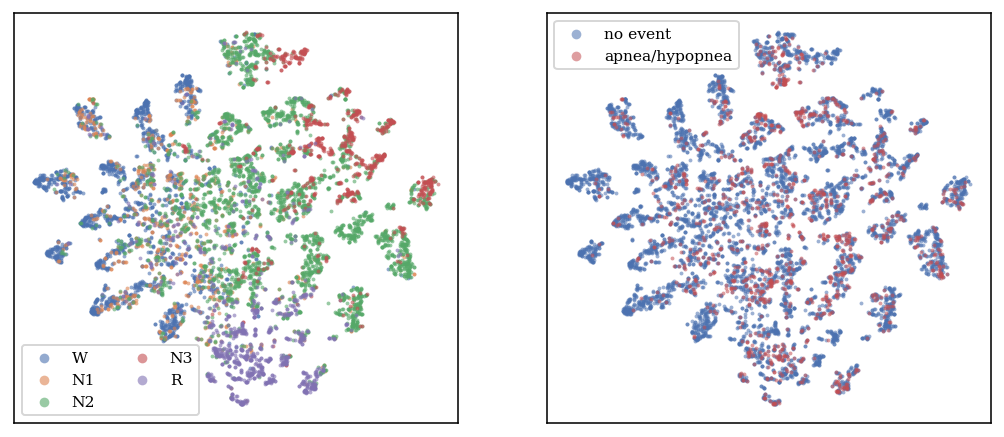

In [6]:
# t-SNE by stage and by respiratory event (legend is a colour key, not an annotation)
idx=np.random.RandomState(0).choice(len(EMB),min(8000,len(EMB)),replace=False)
ts=TSNE(2,perplexity=30,init="pca",random_state=0).fit_transform(PCA(30).fit_transform(EMB[idx]))
st,ap=EY[idx],EA[idx]
fig,ax=plt.subplots(1,2,figsize=(9,3.8))
for k in range(5): ax[0].scatter(*ts[st==k].T,s=4,c=COL[k],label=CLS[k],alpha=.6,lw=0)
ax[0].legend(markerscale=2.5,fontsize=8,ncol=2); ax[0].set_xticks([]); ax[0].set_yticks([])
for v,c,l in [(0,"#4C72B0","no event"),(1,"#C44E52","apnea/hypopnea")]: ax[1].scatter(*ts[ap==v].T,s=4,c=c,label=l,alpha=.55,lw=0)
ax[1].legend(markerscale=2.5,fontsize=8); ax[1].set_xticks([]); ax[1].set_yticks([])
save(fig,"fig_tsne")

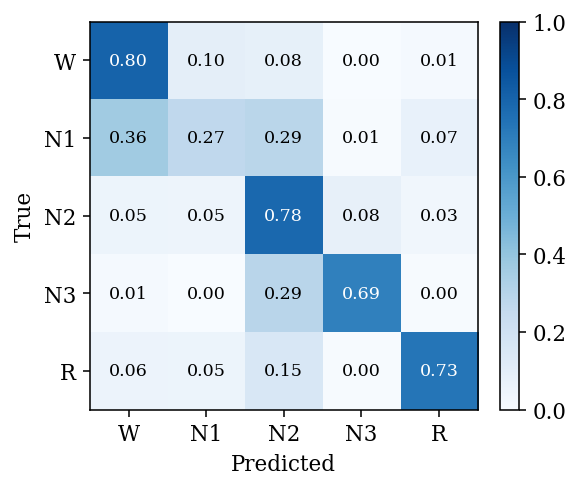

In [7]:
# confusion matrix (cell values are the data of a confusion matrix)
cm=confusion_matrix(YT,YP,labels=range(5)); cmn=cm/cm.sum(1,keepdims=True)
fig,ax=plt.subplots(figsize=(4,3.6)); im=ax.imshow(cmn,cmap="Blues",vmin=0,vmax=1)
for i in range(5):
    for j in range(5): ax.text(j,i,f"{cmn[i,j]:.2f}",ha="center",va="center",color="white" if cmn[i,j]>.5 else "black",fontsize=9)
ax.set_xticks(range(5)); ax.set_xticklabels(CLS); ax.set_yticks(range(5)); ax.set_yticklabels(CLS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); fig.colorbar(im,fraction=0.046); save(fig,"fig_confusion")

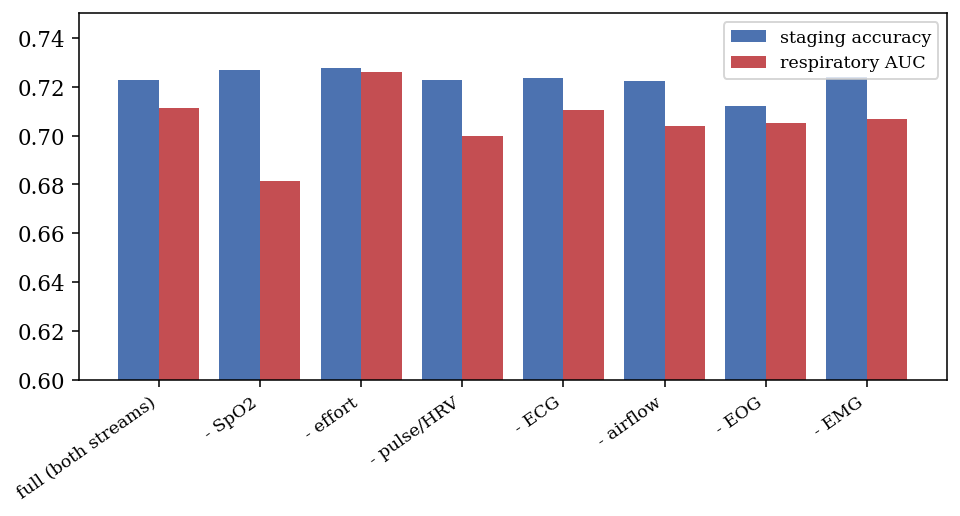

In [8]:
# modality leave-one-out: staging acc and respiratory AUC (grouped bars)
labs=[l for l,_,_ in LOO]; sa=[a for _,a,_ in LOO]; au=[u for _,_,u in LOO]
x=np.arange(len(labs)); fig,ax=plt.subplots(figsize=(8,3.4))
ax.bar(x-0.2,sa,0.4,color="#4C72B0",label="staging accuracy")
ax.bar(x+0.2,au,0.4,color="#C44E52",label="respiratory AUC")
ax.set_xticks(x); ax.set_xticklabels(labs,rotation=35,ha="right",fontsize=9); ax.set_ylim(0.60,0.75); ax.legend(fontsize=9)
save(fig,"fig_ablation")

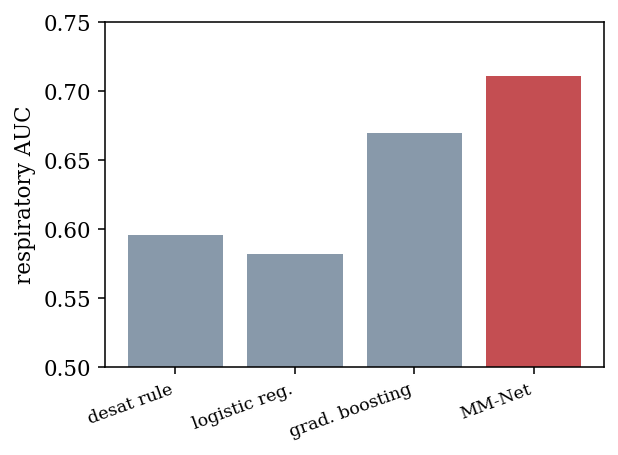

In [9]:
# respiratory baselines vs MM-Net (AUC), values from the main notebook's live baselines cell
names=["desat rule","logistic reg.","grad. boosting","MM-Net"]; aucs=[0.596,0.582,0.670,0.711]
fig,ax=plt.subplots(figsize=(4.6,3.2))
ax.bar(range(4),aucs,color=["#8899AA","#8899AA","#8899AA","#C44E52"])
ax.set_xticks(range(4)); ax.set_xticklabels(names,rotation=20,ha="right",fontsize=9); ax.set_ylabel("respiratory AUC"); ax.set_ylim(0.5,0.75)
save(fig,"fig_resp_baselines")

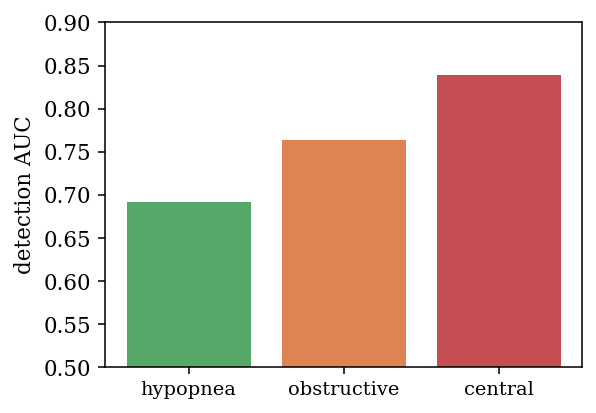

In [10]:
# per-event-type detection AUC
tt=list(pet); fig,ax=plt.subplots(figsize=(4.4,3.2))
ax.bar(range(len(tt)),[pet[t][0] for t in tt],color=["#55A868","#DD8452","#C44E52"][:len(tt)])
ax.set_xticks(range(len(tt))); ax.set_xticklabels(tt,fontsize=10); ax.set_ylabel("detection AUC"); ax.set_ylim(0.5,0.9)
save(fig,"fig_event_type")

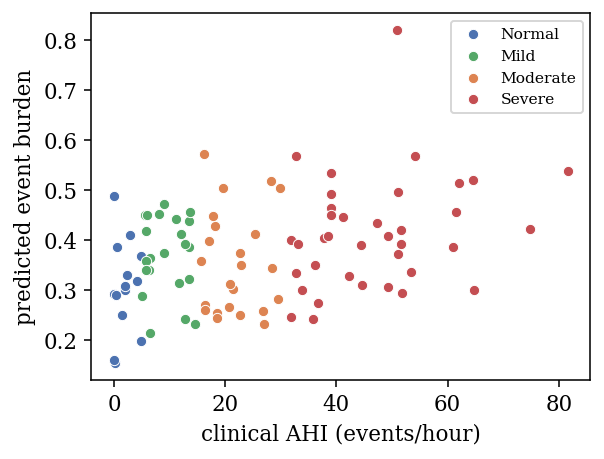

In [11]:
# predicted burden vs clinical AHI, coloured by severity
sc_={"Normal":"#4C72B0","Mild":"#55A868","Moderate":"#DD8452","Severe":"#C44E52"}
fig,ax=plt.subplots(figsize=(4.6,3.4))
for s in SEV:
    m=[i for i,x in enumerate(sev) if x==s]
    if m: ax.scatter(np.array(clin)[m],np.array(burden)[m],s=28,c=sc_[s],label=s,edgecolor="white",linewidth=.5)
ax.set_xlabel("clinical AHI (events/hour)"); ax.set_ylabel("predicted event burden"); ax.legend(fontsize=8)
save(fig,"fig_ahi")

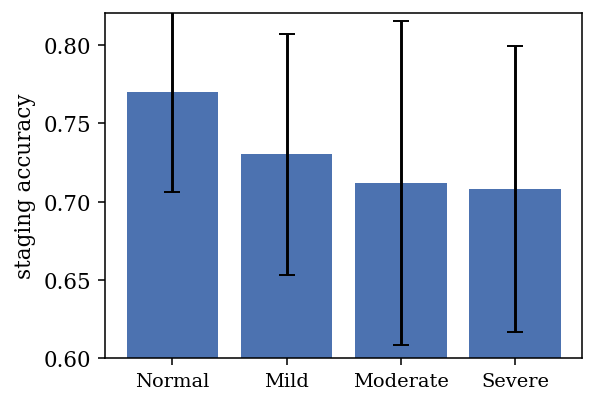

In [12]:
# staging accuracy by SDB severity
order=[s for s in SEV if s in sev_acc]; fig,ax=plt.subplots(figsize=(4.4,3.2))
ax.bar(range(len(order)),[sev_acc[s][0] for s in order],yerr=[sev_acc[s][1] for s in order],capsize=4,color="#4C72B0")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order,fontsize=10); ax.set_ylabel("staging accuracy"); ax.set_ylim(0.6,0.82)
save(fig,"fig_severity")

Supplementary complete. Corrected AHI, per-event-type, severity, and all clean figures produced and saved.